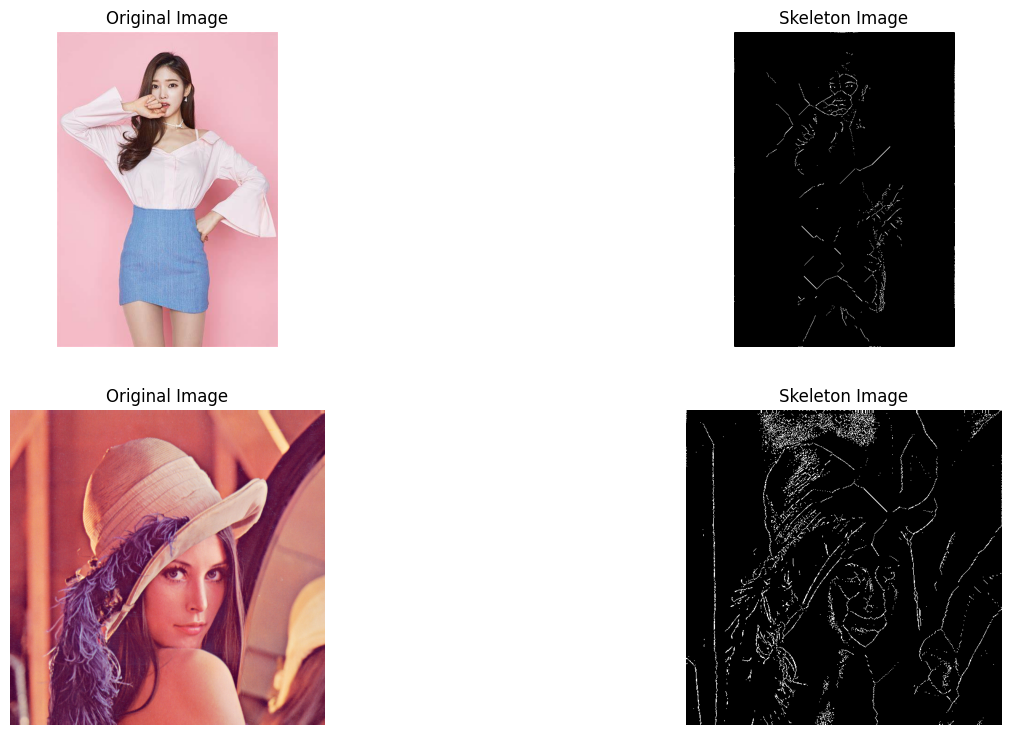

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def extract_skeleton(image):
    # 将图像转换为灰度图
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    # 二值化处理
    _, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
    
    # 初始化结构元素
    element = cv2.getStructuringElement(cv2.MORPH_CROSS, (3, 3))
    skeleton = np.zeros(binary.shape, np.uint8)
    
    # 迭代提取骨架
    while True:
        # 开运算
        open_img = cv2.morphologyEx(binary, cv2.MORPH_OPEN, element)
        # 提取边界
        temp = cv2.subtract(binary, open_img)
        # 组合到骨架图像中
        skeleton = cv2.bitwise_or(skeleton, temp)
        # 腐蚀
        binary = cv2.erode(binary, element)
        
        # 检查是否已经提取完毕
        if cv2.countNonZero(binary) == 0:
            break
    
    return skeleton

# 加载输入图像
image = cv2.imread('female.jpg')
skeleton = extract_skeleton(image)

image2 = cv2.imread("lena.bmp")
skeleton2 = extract_skeleton(image2)


# 使用 matplotlib 显示原始图像和骨架图像
plt.figure(figsize=(16, 9))

# 显示原始图像
plt.subplot(2, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

# 显示骨架图像
plt.subplot(2, 2, 2)
plt.imshow(skeleton, cmap="gray")
plt.title("Skeleton Image")
plt.axis("off")


# 显示原始图像
plt.subplot(2, 2, 3)
plt.imshow(cv2.cvtColor(image2, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

# 显示骨架图像
plt.subplot(2, 2, 4)
plt.imshow(skeleton2, cmap="gray")
plt.title("Skeleton Image")
plt.axis("off")

# 展示图像
plt.show()
